In [98]:
import os
import json

import pandas as pd
import matplotlib.pyplot as plt

from dotenv import load_dotenv
from openai import OpenAI
from pygments import highlight
from pygments.lexers import JsonLexer
from pygments.formatters import HtmlFormatter
from IPython.display import HTML, Markdown, display
from matplotlib.patches import Patch


MODEL_NAME = "gpt-4.1-mini"

In [99]:
# create OpenAI client
load_dotenv(override=True)
api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI(api_key=api_key)

In [ ]:
# function to generate analysis using the OpenAI API
def generate_analysis(prompt):
    """Generates analysis based on the provided prompt using the OpenAI API."""

    response = client.chat.completions.create(
        model=MODEL_NAME,
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a senior programme delivery consultant "
                    "specialising in software delivery risk."
                )
            },
            {
                "role": "user",
                "content": prompt
            }
        ]
    )

    return response

# helper function to display results in a readable format
def pretty(obj):
    """Formats and displays the given object in a readable way."""

    if isinstance(obj, str):

        print(obj)

    else:

        formatted_json = json.dumps(
            obj,
            indent=2
        )

        formatter = HtmlFormatter(
            style="monokai"
        )

        html = (
            "<style>"
            + formatter.get_style_defs(".highlight")
            + "</style>"
            + highlight(
                formatted_json,
                JsonLexer(),
                formatter
            )
        )

        display(HTML(html))

In [101]:
# read in dataset
df = pd.read_csv('../data/project_data.csv')
df.head()

,Project,Status,Budget,ActualCost,DelayDays,RiskLevel
0,Apollo,Complete,100000,120000,15,High
1,Mercury,In Progress,80000,75000,2,Low
2,Gemini,Delayed,150000,180000,30,High
3,Orion,Complete,50000,45000,0,Low
4,Phoenix,In Progress,120000,140000,10,Medium


In [102]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   Project     10 non-null     str  
 1   Status      10 non-null     str  
 2   Budget      10 non-null     int64
 3   ActualCost  10 non-null     int64
 4   DelayDays   10 non-null     int64
 5   RiskLevel   10 non-null     str  
dtypes: int64(3), str(3)
memory usage: 612.0 bytes


In [103]:
df.describe()

,Budget,ActualCost,DelayDays
count,10.000000,10.000000,10.000000
mean,105500.000000,117200.000000,12.100000
std,45853.026072,58520.271891,11.130039
min,50000.000000,45000.000000,0.000000
25%,72500.000000,69750.000000,1.250000
50%,97500.000000,115000.000000,12.500000
75%,127500.000000,143750.000000,19.500000
max,200000.000000,230000.000000,30.000000


In [104]:
# create metrics
df['CostVariance'] = df['ActualCost'] - df['Budget']
df['CostVariancePct'] = (df['CostVariance'] / df['Budget']) * 100

average_delay = df['DelayDays'].mean()
high_risk_count = (df['RiskLevel'] == 'High').sum()
average_cost_variance_pct = df['CostVariancePct'].mean()
correlation = df["DelayDays"].corr(df["CostVariancePct"])
variance_by_risk = df.groupby("RiskLevel")["CostVariancePct"].mean()

# identify high-risk projects based on multiple criteria
high_risk_df = df[
    (df["RiskLevel"] == "High")
    | (df["DelayDays"] > 10)
    | (df["CostVariancePct"] > 10)
]

high_risk_count = len(high_risk_df)
high_risk_records = high_risk_df.to_dict(orient="records")



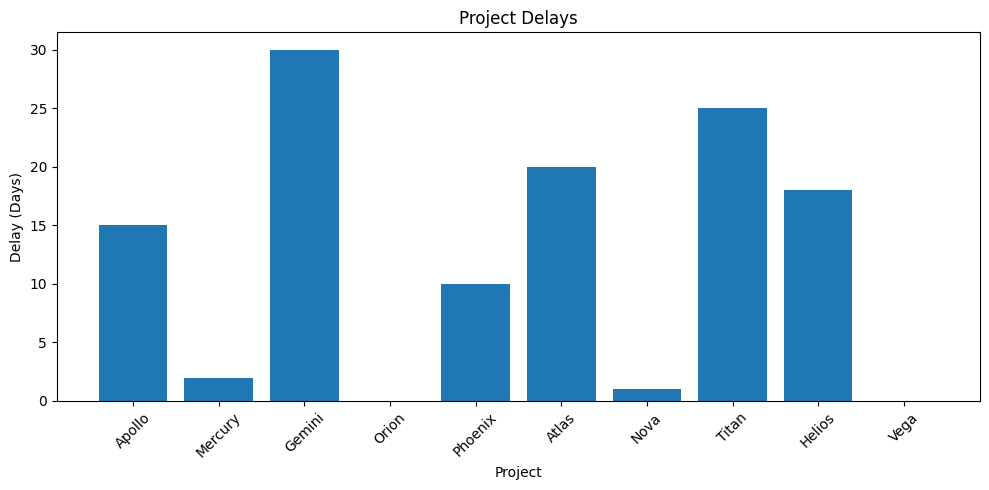

In [105]:
# create project delays bar chart   
plt.figure(figsize=(10,5))
plt.bar(df["Project"], df["DelayDays"])
plt.xticks(rotation=45)
plt.title("Project Delays")
plt.xlabel("Project")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()

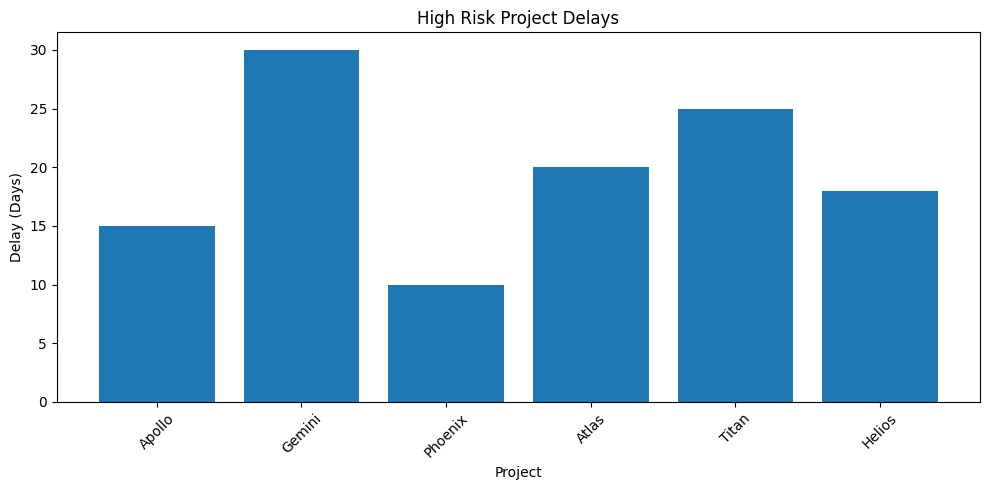

In [106]:
# crreate high-risk project delays bar chart
plt.figure(figsize=(10,5))
plt.bar(high_risk_df["Project"], high_risk_df["DelayDays"])
plt.xticks(rotation=45)
plt.title("High Risk Project Delays")
plt.xlabel("Project")
plt.ylabel("Delay (Days)")
plt.tight_layout()
plt.show()

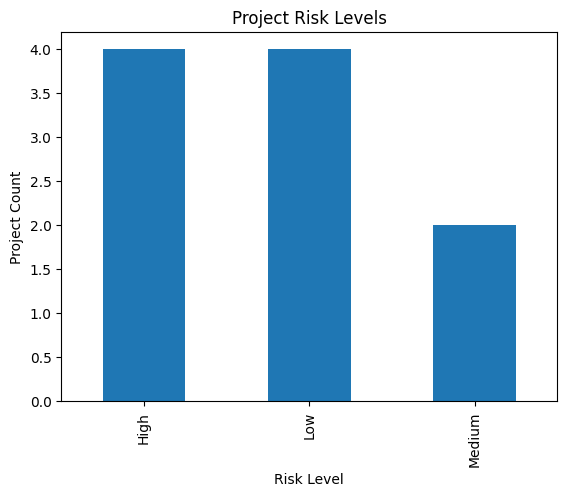

In [107]:
# create project risk level distribution bar chart
risk_counts = df["RiskLevel"].value_counts()
risk_counts.plot(kind="bar")

plt.title("Project Risk Levels")
plt.xlabel("Risk Level")
plt.ylabel("Project Count")

plt.show()

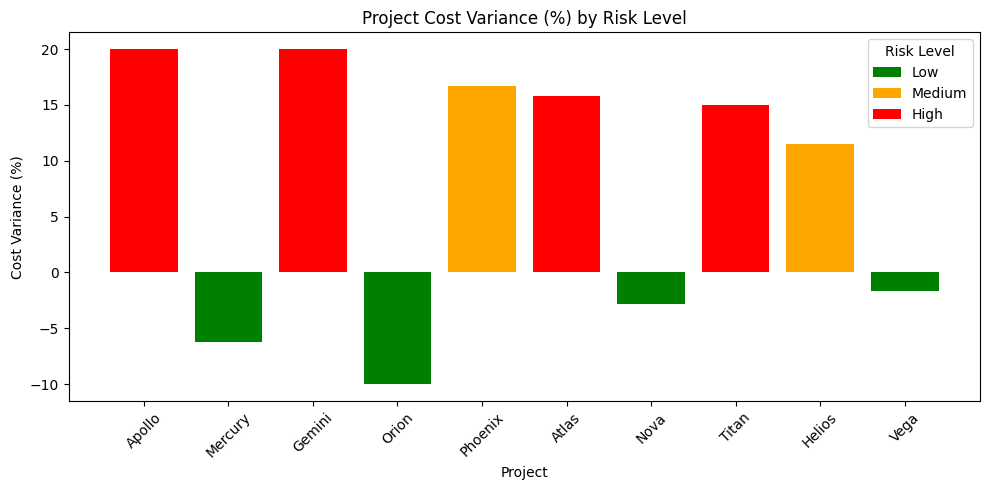

In [108]:
risk_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}

colors = [
    risk_colors[risk]
    for risk in df["RiskLevel"]
]

plt.figure(figsize=(10, 5))

plt.bar(
    df["Project"],
    df["CostVariancePct"],
    color=colors
)

legend_elements = [
    Patch(facecolor="green", label="Low"),
    Patch(facecolor="orange", label="Medium"),
    Patch(facecolor="red", label="High")
]

plt.legend(
    handles=legend_elements,
    title="Risk Level"
)

plt.xticks(rotation=45)

plt.title("Project Cost Variance (%) by Risk Level")
plt.xlabel("Project")
plt.ylabel("Cost Variance (%)")

plt.tight_layout()

plt.show()

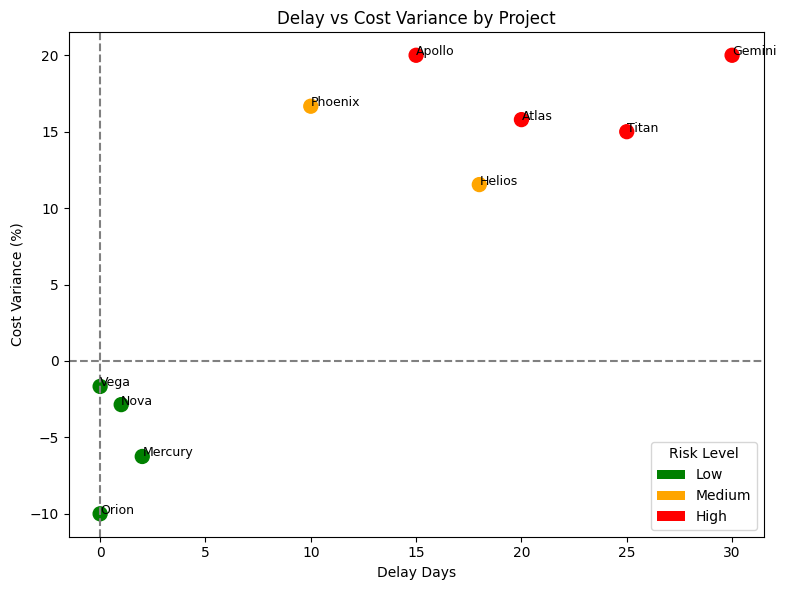

In [109]:
risk_colors = {
    "Low": "green",
    "Medium": "orange",
    "High": "red"
}

colors = [
    risk_colors[risk]
    for risk in df["RiskLevel"]
]

plt.figure(figsize=(8, 6))

plt.scatter(
    df["DelayDays"],
    df["CostVariancePct"],
    c=colors,
    s=100
)

for i, project in enumerate(df["Project"]):

    plt.text(
        df["DelayDays"][i],
        df["CostVariancePct"][i],
        project,
        fontsize=9
    )

legend_elements = [
    Patch(facecolor="green", label="Low"),
    Patch(facecolor="orange", label="Medium"),
    Patch(facecolor="red", label="High")
]

plt.legend(
    handles=legend_elements,
    title="Risk Level"
)

plt.title("Delay vs Cost Variance by Project")

plt.xlabel("Delay Days")

plt.ylabel("Cost Variance (%)")

plt.axhline(
    0,
    color="grey",
    linestyle="--"
)

plt.axvline(
    0,
    color="grey",
    linestyle="--"
)

plt.tight_layout()

plt.show()

In [110]:
analysis_prompt = f"""
You are a senior programme delivery consultant.

Portfolio metrics:

- High-risk projects: {high_risk_count}
- Average delay: {average_delay:.1f} days
- Average cost variance: {average_cost_variance_pct:.1f}%
- Delay/cost variance correlation: {correlation:.2f}

High risk project records:

{json.dumps(high_risk_records, indent=2)}

Return your response in markdown with these sections:

## Executive Summary

## Observations
Clearly distinguish observed facts from inferred risks.

## Key Risks
Include reasonable interpretations, but clearly distinguish them from observed facts.

## Recommended Actions
Provide practical delivery management actions.

Keep the tone concise and professional.
Only reference issues directly supported by the dataset.

"""

In [111]:
response = generate_analysis(analysis_prompt)
response_content = response.choices[0].message.content
display(Markdown(response_content))

## Executive Summary

The portfolio contains 6 high-risk projects with an average delay of 12.1 days and an average cost variance of 7.8%. There is a strong positive correlation (0.86) between project delays and cost variances, indicating that schedule slippage strongly drives budget overruns. Among the high-risk projects, 3 are delayed and 2 are in progress, with cost variances ranging from 11.5% to 20%. Notably, completed and delayed projects exhibit significant cost overruns.

## Observations

- Total high-risk projects: 6 (Apollo, Gemini, Phoenix, Atlas, Titan, Helios).
- Status breakdown of high-risk projects: 1 Complete (Apollo), 3 Delayed (Gemini, Atlas, Helios), 2 In Progress (Phoenix, Titan).
- Apollo: Completed with 15 days delay and 20% cost variance.
- Gemini: Delayed by 30 days with 20% cost variance.
- Atlas: Delayed by 20 days with 15.8% cost variance.
- Titan: In Progress with 25 days delay and 15% cost variance.
- Phoenix and Helios marked as Medium risk but included in dataset; Phoenix In Progress (10 days delay, 16.7% cost variance), Helios Delayed (18 days delay, 11.5% cost variance).
- Delay and cost variances are positively correlated (0.86), confirming schedule slippage impacts financial outcomes.

## Key Risks

- High proportion of delayed projects among high-risk category signals ongoing schedule management issues.
- Projects with higher delays (>20 days) correspond with higher cost overruns (≥15%), increasing budget risk exposure.
- Completed high-risk projects conclude with significant cost overruns, highlighting possible deficiencies in forecasting or control during delivery.
- Medium risk projects included demonstrate meaningful delays and cost variance, suggesting possible risk underclassification or emerging issues.
- Financial risk is compounded by schedule delays, emphasizing that timelines directly affect budget outcomes.

## Recommended Actions

- Strengthen schedule tracking and apply more rigorous milestone controls on high-risk projects to reduce delay impact.
- Increase financial oversight for projects exhibiting early delay signs to mitigate escalating cost overruns.
- Reassess risk categorization protocols to ensure projects with elevated delay and cost variance (like Phoenix and Helios) are classified appropriately for focused intervention.
- Conduct root cause analysis on completed projects with high cost variance (e.g., Apollo) to extract lessons and improve future cost predictability.
- Implement corrective action plans for delayed projects, focusing on resource allocation, scope management, and risk mitigation strategies.
- Enhance communication between delivery and finance teams to ensure timely adjustments and transparency in budget forecasting tied to project schedules.